In [7]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Get the project root directory
project_root = Path.cwd()
sys.path.append(str(project_root.parent))

from notebook_imports import *

In [9]:
# Set project directories using configuration
home_dir = str(config.PROJECT_ROOT)
data_dir = str(config.DATA_DIR)
resources_dir = str(config.RESOURCES_DIR)
results_dir = str(config.RESULTS_03_DIR)
figures_dir = str(config.FIGURES_03_DIR)

In [20]:
def process_performances(cell_line):
    GEARS_evaluation = pd.read_csv(os.path.join(results_dir, f'sciplex{cell_line}_GEARS_outcomes.csv'))
    GEARSnoreg_evaluation = pd.read_csv(os.path.join(results_dir, f'sciplex{cell_line}_GEARS_noreg_outcomes.csv'))
    scfoundation_evaluation = pd.read_csv(os.path.join(results_dir, f'sciplex{cell_line}_scfoundation_outcomes.csv'))
    CPA_evaluation = pd.read_csv(os.path.join(results_dir, f'sciplex{cell_line}_cpa_outcomes.csv'))
    no_effect_evaluation = pd.read_csv(os.path.join(results_dir, f'sciplex{cell_line}_no_effect_outcomes.csv'))
    average_effect_evaluation = pd.read_csv(os.path.join(results_dir, f'sciplex{cell_line}_average_effect_outcomes.csv'))
    pert_to_drug = pd.read_csv(os.path.join(resources_dir, f'sciplex_drug_to_perturbation.csv'), index_col=0)
    pert_to_drug['product_name'] = pert_to_drug['product_name'].str.replace(' ', '')

    GEARS_evaluation['model'] = 'GEARS'
    scfoundation_evaluation['model'] = 'scFoundation'
    GEARSnoreg_evaluation['model'] = 'GEARS\nOptimized'
    CPA_evaluation['model'] = 'CPA'
    no_effect_evaluation['model'] = 'No effect'
    average_effect_evaluation['model'] = 'Average effect'


    outcomes = pd.concat([GEARS_evaluation,
                            scfoundation_evaluation,
                            CPA_evaluation,
                            GEARSnoreg_evaluation,
                            no_effect_evaluation,
                            average_effect_evaluation], axis=0).dropna()

    outcomes['cell_type_condition'] = outcomes['cell_type'] + '_' + outcomes['condition']

    
    return outcomes


## Evaluate sciplex predictions

In [21]:
mcf7_outcomes = process_performances('mcf7')
a549_outcomes = process_performances('a549')
k562_outcomes = process_performances('k562')

all_outcomes = pd.concat([mcf7_outcomes, a549_outcomes, k562_outcomes], axis=0)

Save.

In [ ]:
all_outcomes.to_csv(os.path.join(results_dir, 'sciplex_all_outcomes.csv'), index=False)

In [23]:
def plot_performances_boxplot(all_outcomes, figures_dir):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=300)
    axes = axes.flatten()


    color_palette = sns.color_palette([
        "#1f77b4",  # Model A - blue
        "#2ca02c",  # Model B Config 1 - green
        "#98df8a",  # Model B Config 2 - light green
        "#ff7f0e",  # Model C - orange
        "#7f7f7f",  # Baseline 1 - gray
        "#4d4d4d",  # Baseline 2 - dark gray
    ])
    colors = {
        'CPA': color_palette[0],
        'GEARS': color_palette[1],
        'GEARS\nOptimized': color_palette[2],
        'scFoundation': color_palette[3],
        'Average effect': color_palette[5],
        'No effect': color_palette[4]
    }

    all_outcomes['model'] = pd.Categorical(
        all_outcomes['model'],
        categories=[ 'CPA','GEARS', 'GEARS\nOptimized', 'scFoundation', 'No effect', 'Average effect'],
        ordered=True
    )

    label_dict = {
        'mse': r'MSE (all genes) $\leftarrow$',
        'pearson': r'Pearson r (all genes) $\rightarrow$',
        'mse_de': r' MSE (top20 DE) $\leftarrow$',
        'pearson_de': r'Pearson r (top20 DE) $\rightarrow$'
    }

    for i, metric in enumerate(['mse', 'pearson', 'mse_de', 'pearson_de']):
        data_subset = all_outcomes[all_outcomes['metric'] == metric]
        ax = axes[i]

        sns.boxplot(x='model', y='value', color='.8', data=data_subset, ax=ax)
        sns.swarmplot(x='model', y='value', data=data_subset, palette=colors, ax=ax)

        ax.set_ylabel(label_dict[metric], fontsize=16)
        ax.set_xlabel('')
        ax.set_title('')
        ax.set_yscale('log' if 'mse' in metric else 'linear')
        ax.set_ylim(
            [1e-5, all_outcomes[all_outcomes['metric'] == 'mse_de']['value'].max() * 1.4] if 'mse' in metric else [-0.5, 1.1]
        )
        ax.tick_params(axis='x', labelsize=14)

        sns.despine(ax=ax, offset=10, trim=False)

        # --- Save each individual subplot ---
        subfig = plt.figure(figsize=(8, 5), dpi=300)
        subax = subfig.add_axes([0.15, 0.15, 0.75, 0.75])  # [left, bottom, width, height]

        sns.boxplot(x='model', y='value', color='.8', data=data_subset, ax=subax)
        sns.swarmplot(x='model', y='value', data=data_subset, palette=colors, ax=subax)

        subax.set_ylabel(label_dict[metric], fontsize=18)
        subax.set_xlabel('')
        subax.set_yscale('log' if 'mse' in metric else 'linear')
        subax.set_ylim(ax.get_ylim())
        subax.tick_params(axis='x', labelsize=14, rotation=45)
                # set rotation & alignment of labels
        subax.set_xticklabels(subax.get_xticklabels(),
                            rotation=45, ha='right', rotation_mode='anchor')
        ax.yaxis.set_tick_params(labelsize=14)

        sns.despine(ax=subax, offset=10, trim=False)

        subfig.tight_layout()
        subfig.savefig(os.path.join(figures_dir, f'performance_boxplot_{metric}.pdf'), bbox_inches='tight')
        # plt.close(subfig)

    return fig, axes


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_15856\1129471447.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='model', y='value', data=data_subset, palette=colors, ax=ax)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 90.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 86.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 69.7% of the points canno

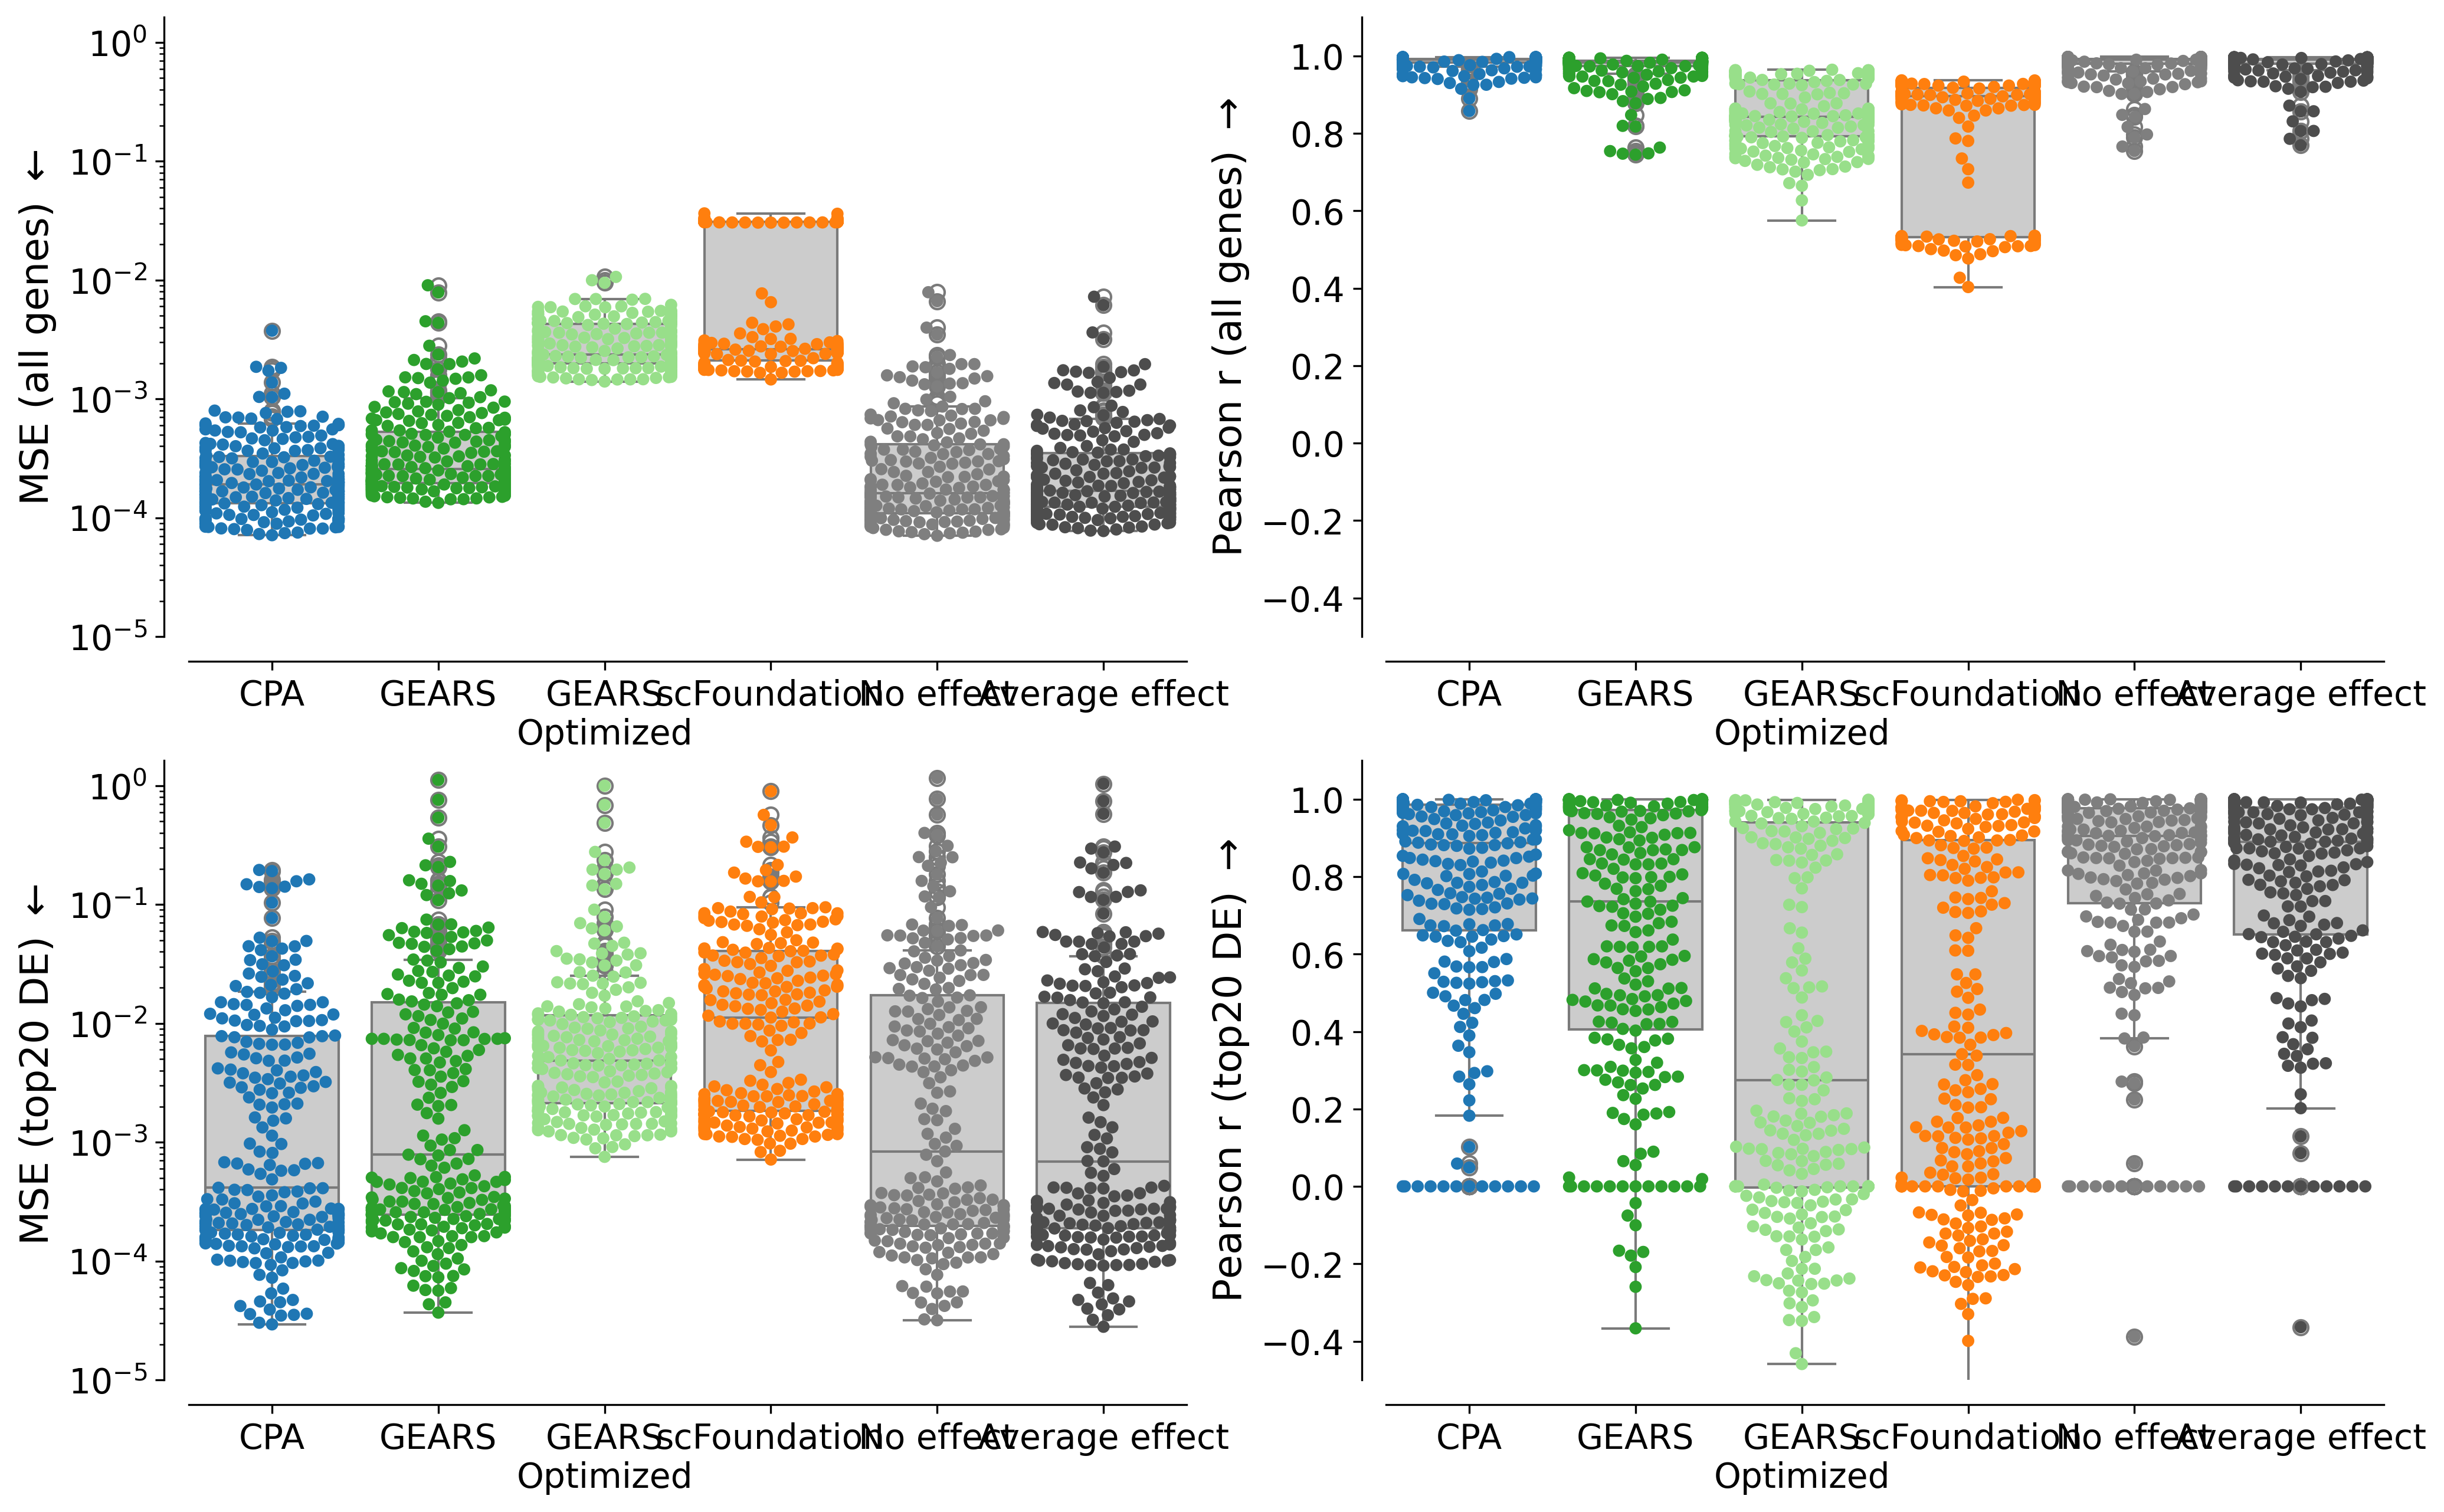

c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 44.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 63.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 75.8% of the points cannot be placed; you may want to decrease the size of the markers or use strip

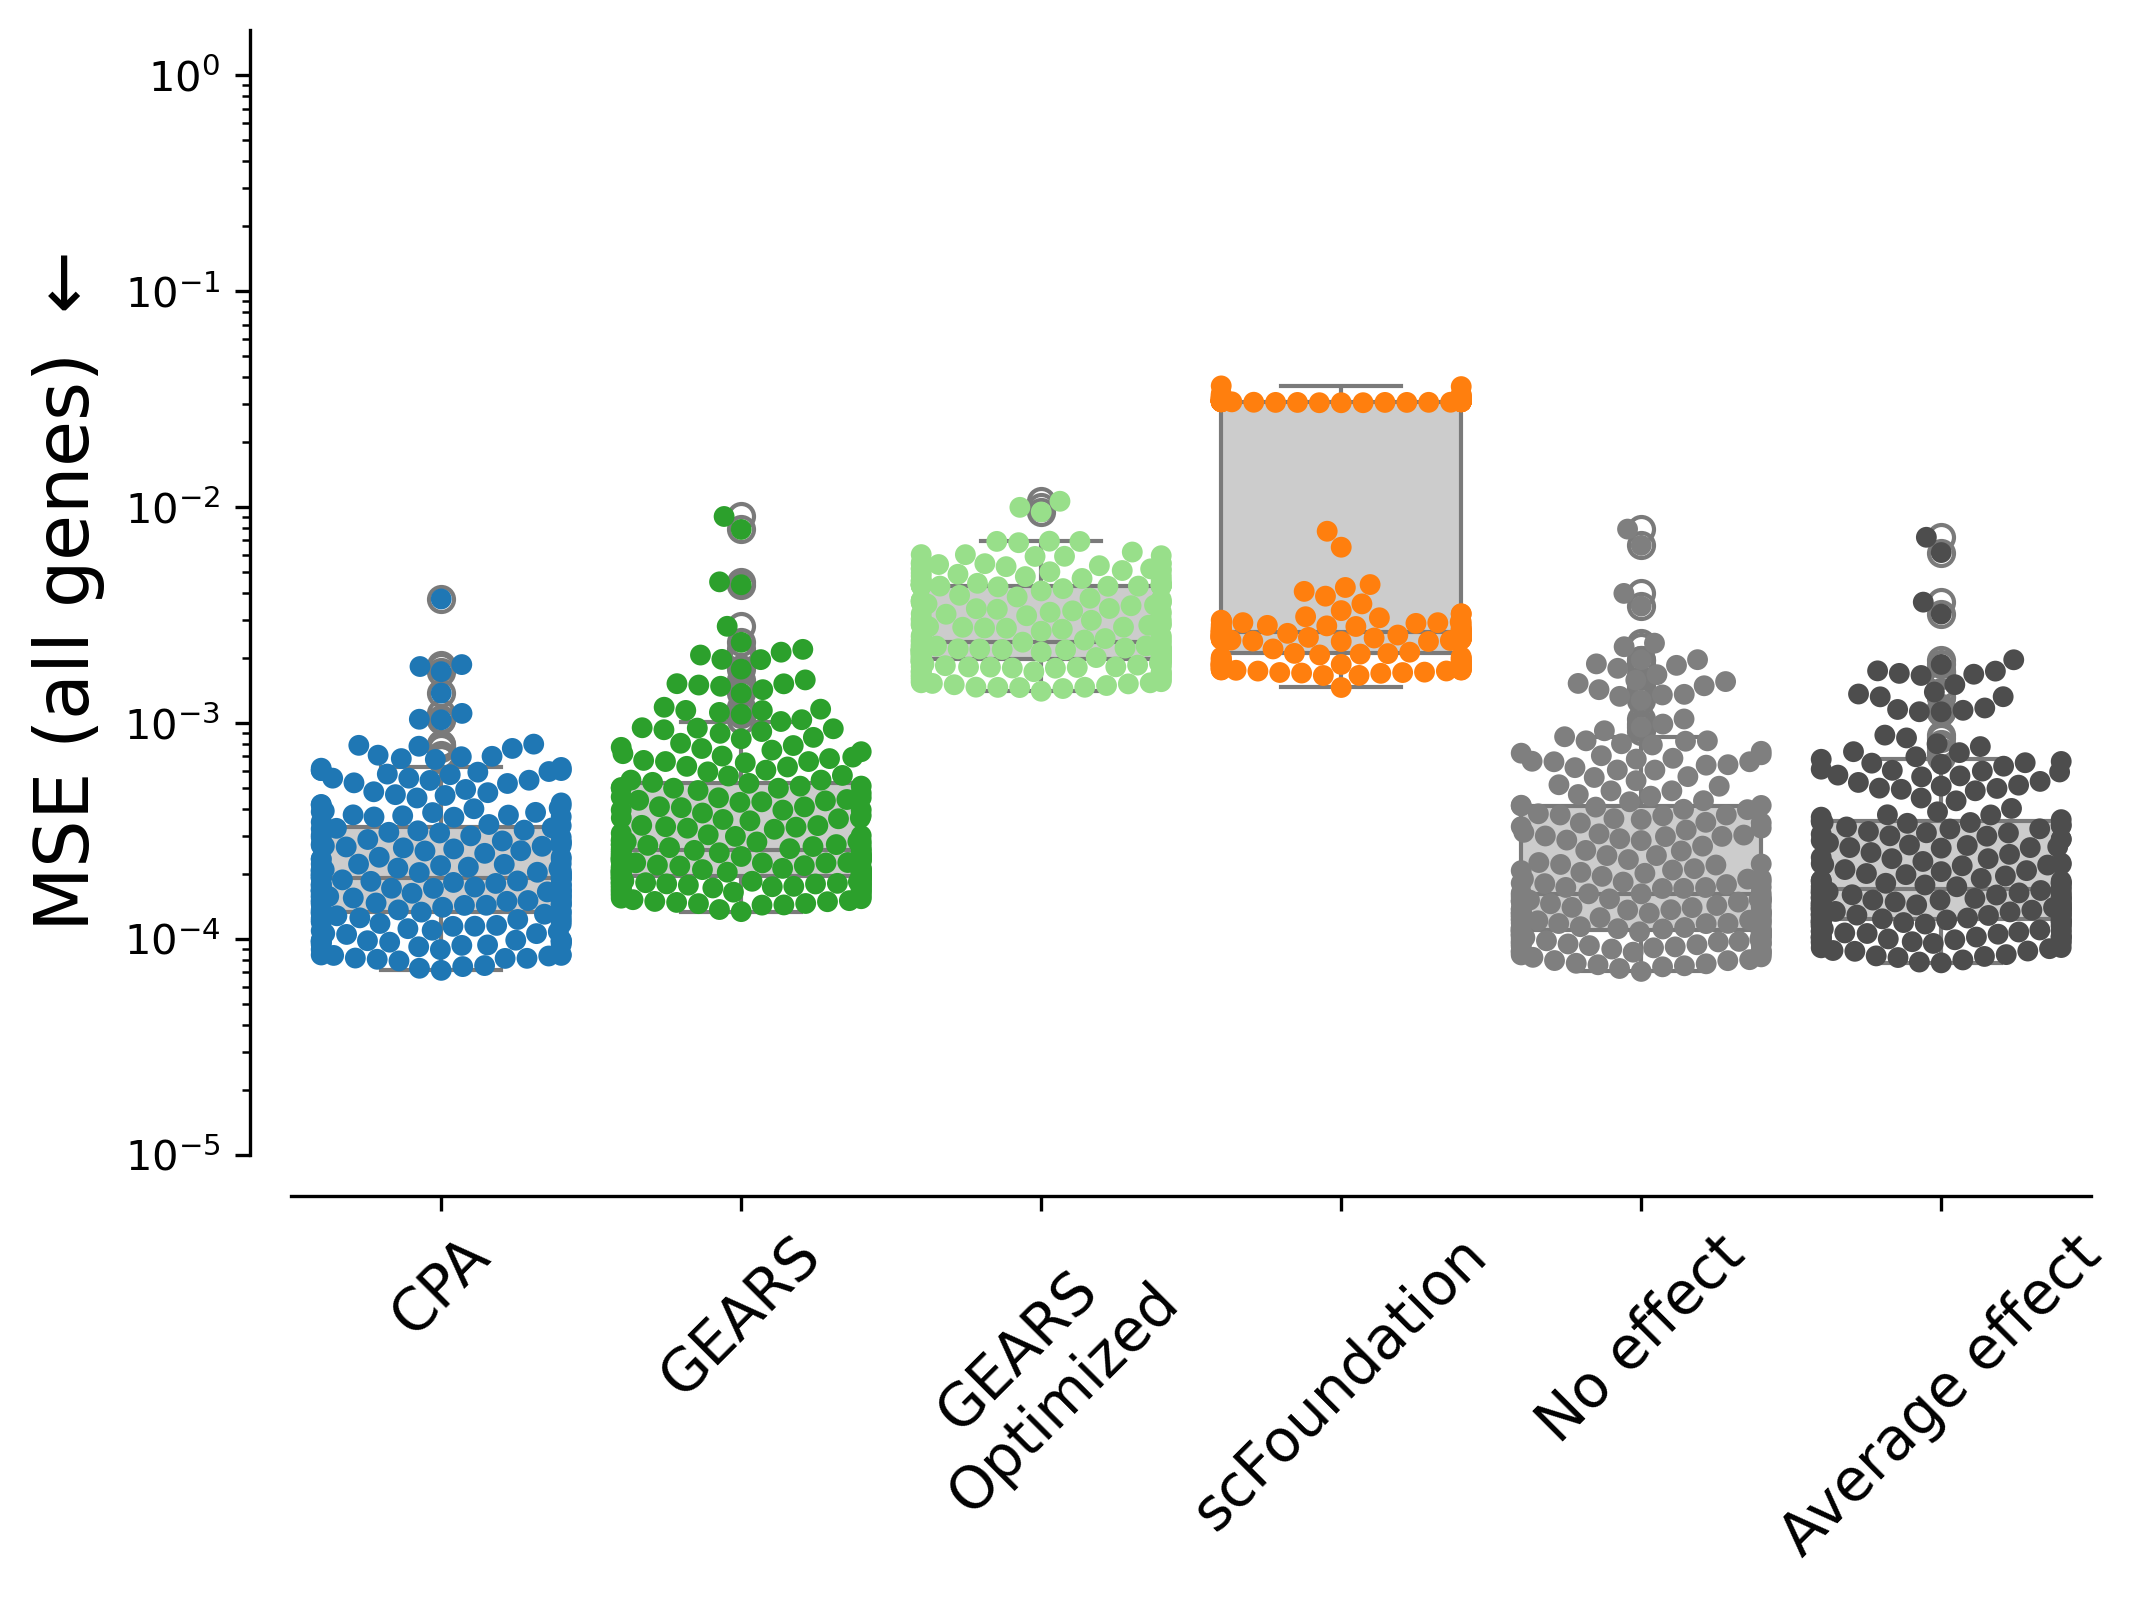

c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 86.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 79.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 72.7% of the points cannot be placed; you may want to decrease the size of the markers or use strip

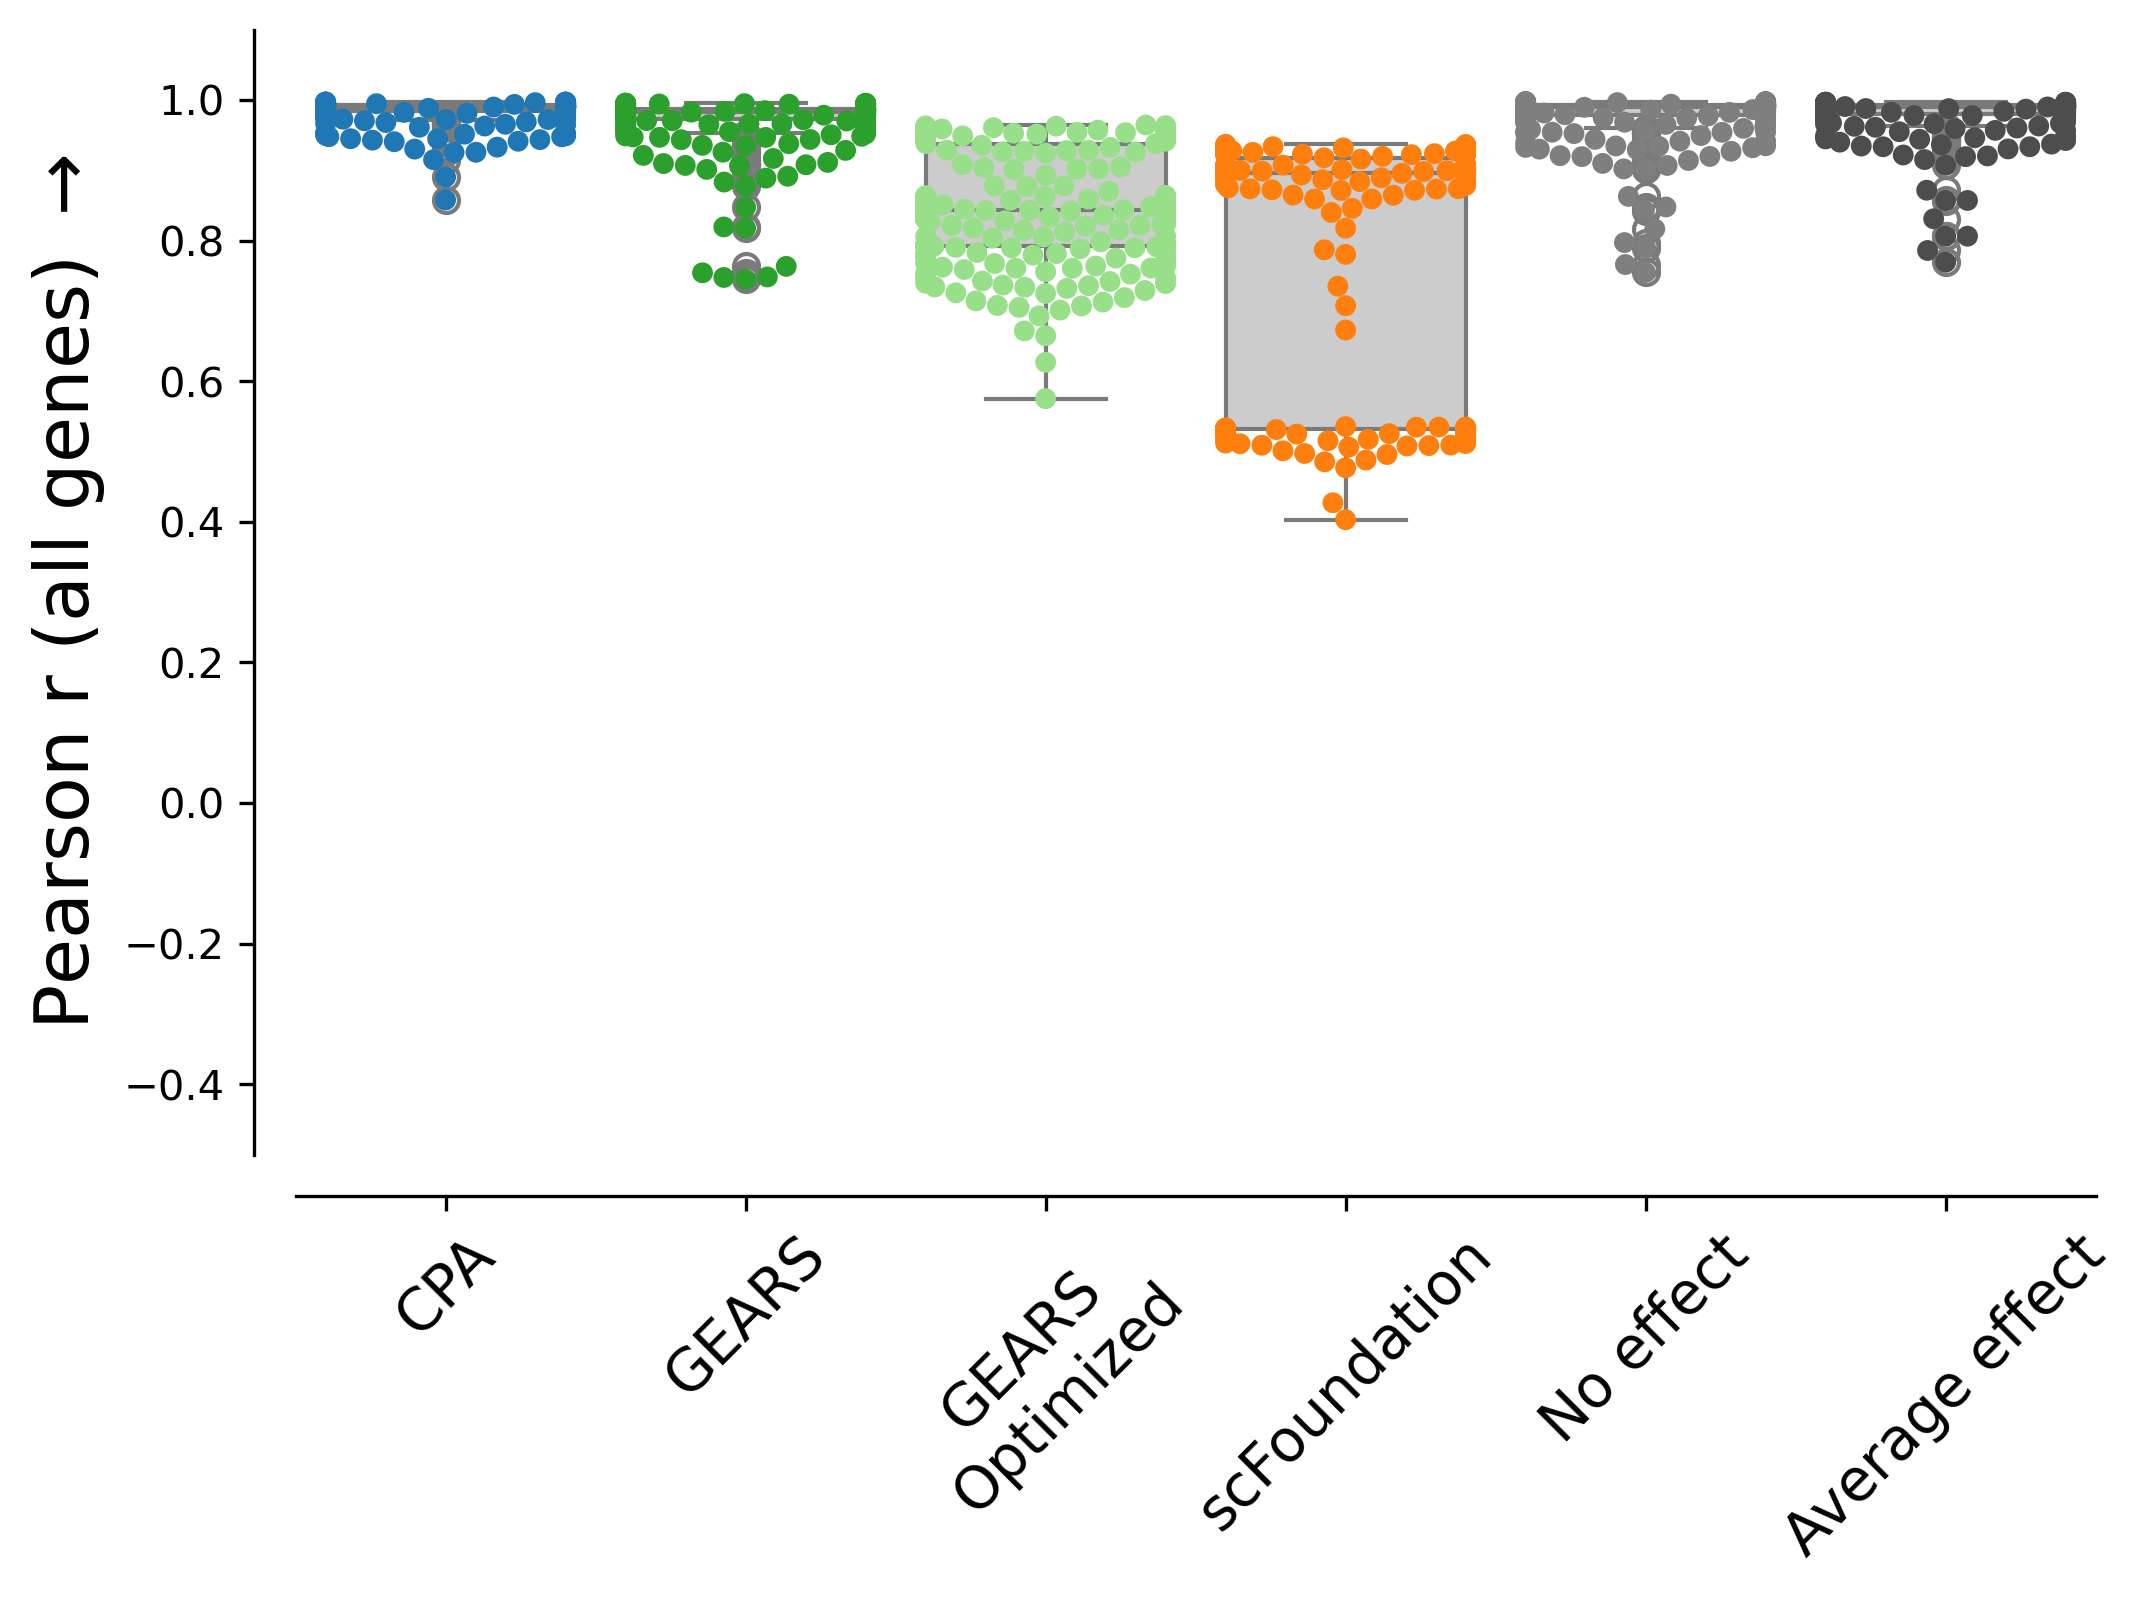

c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use strip

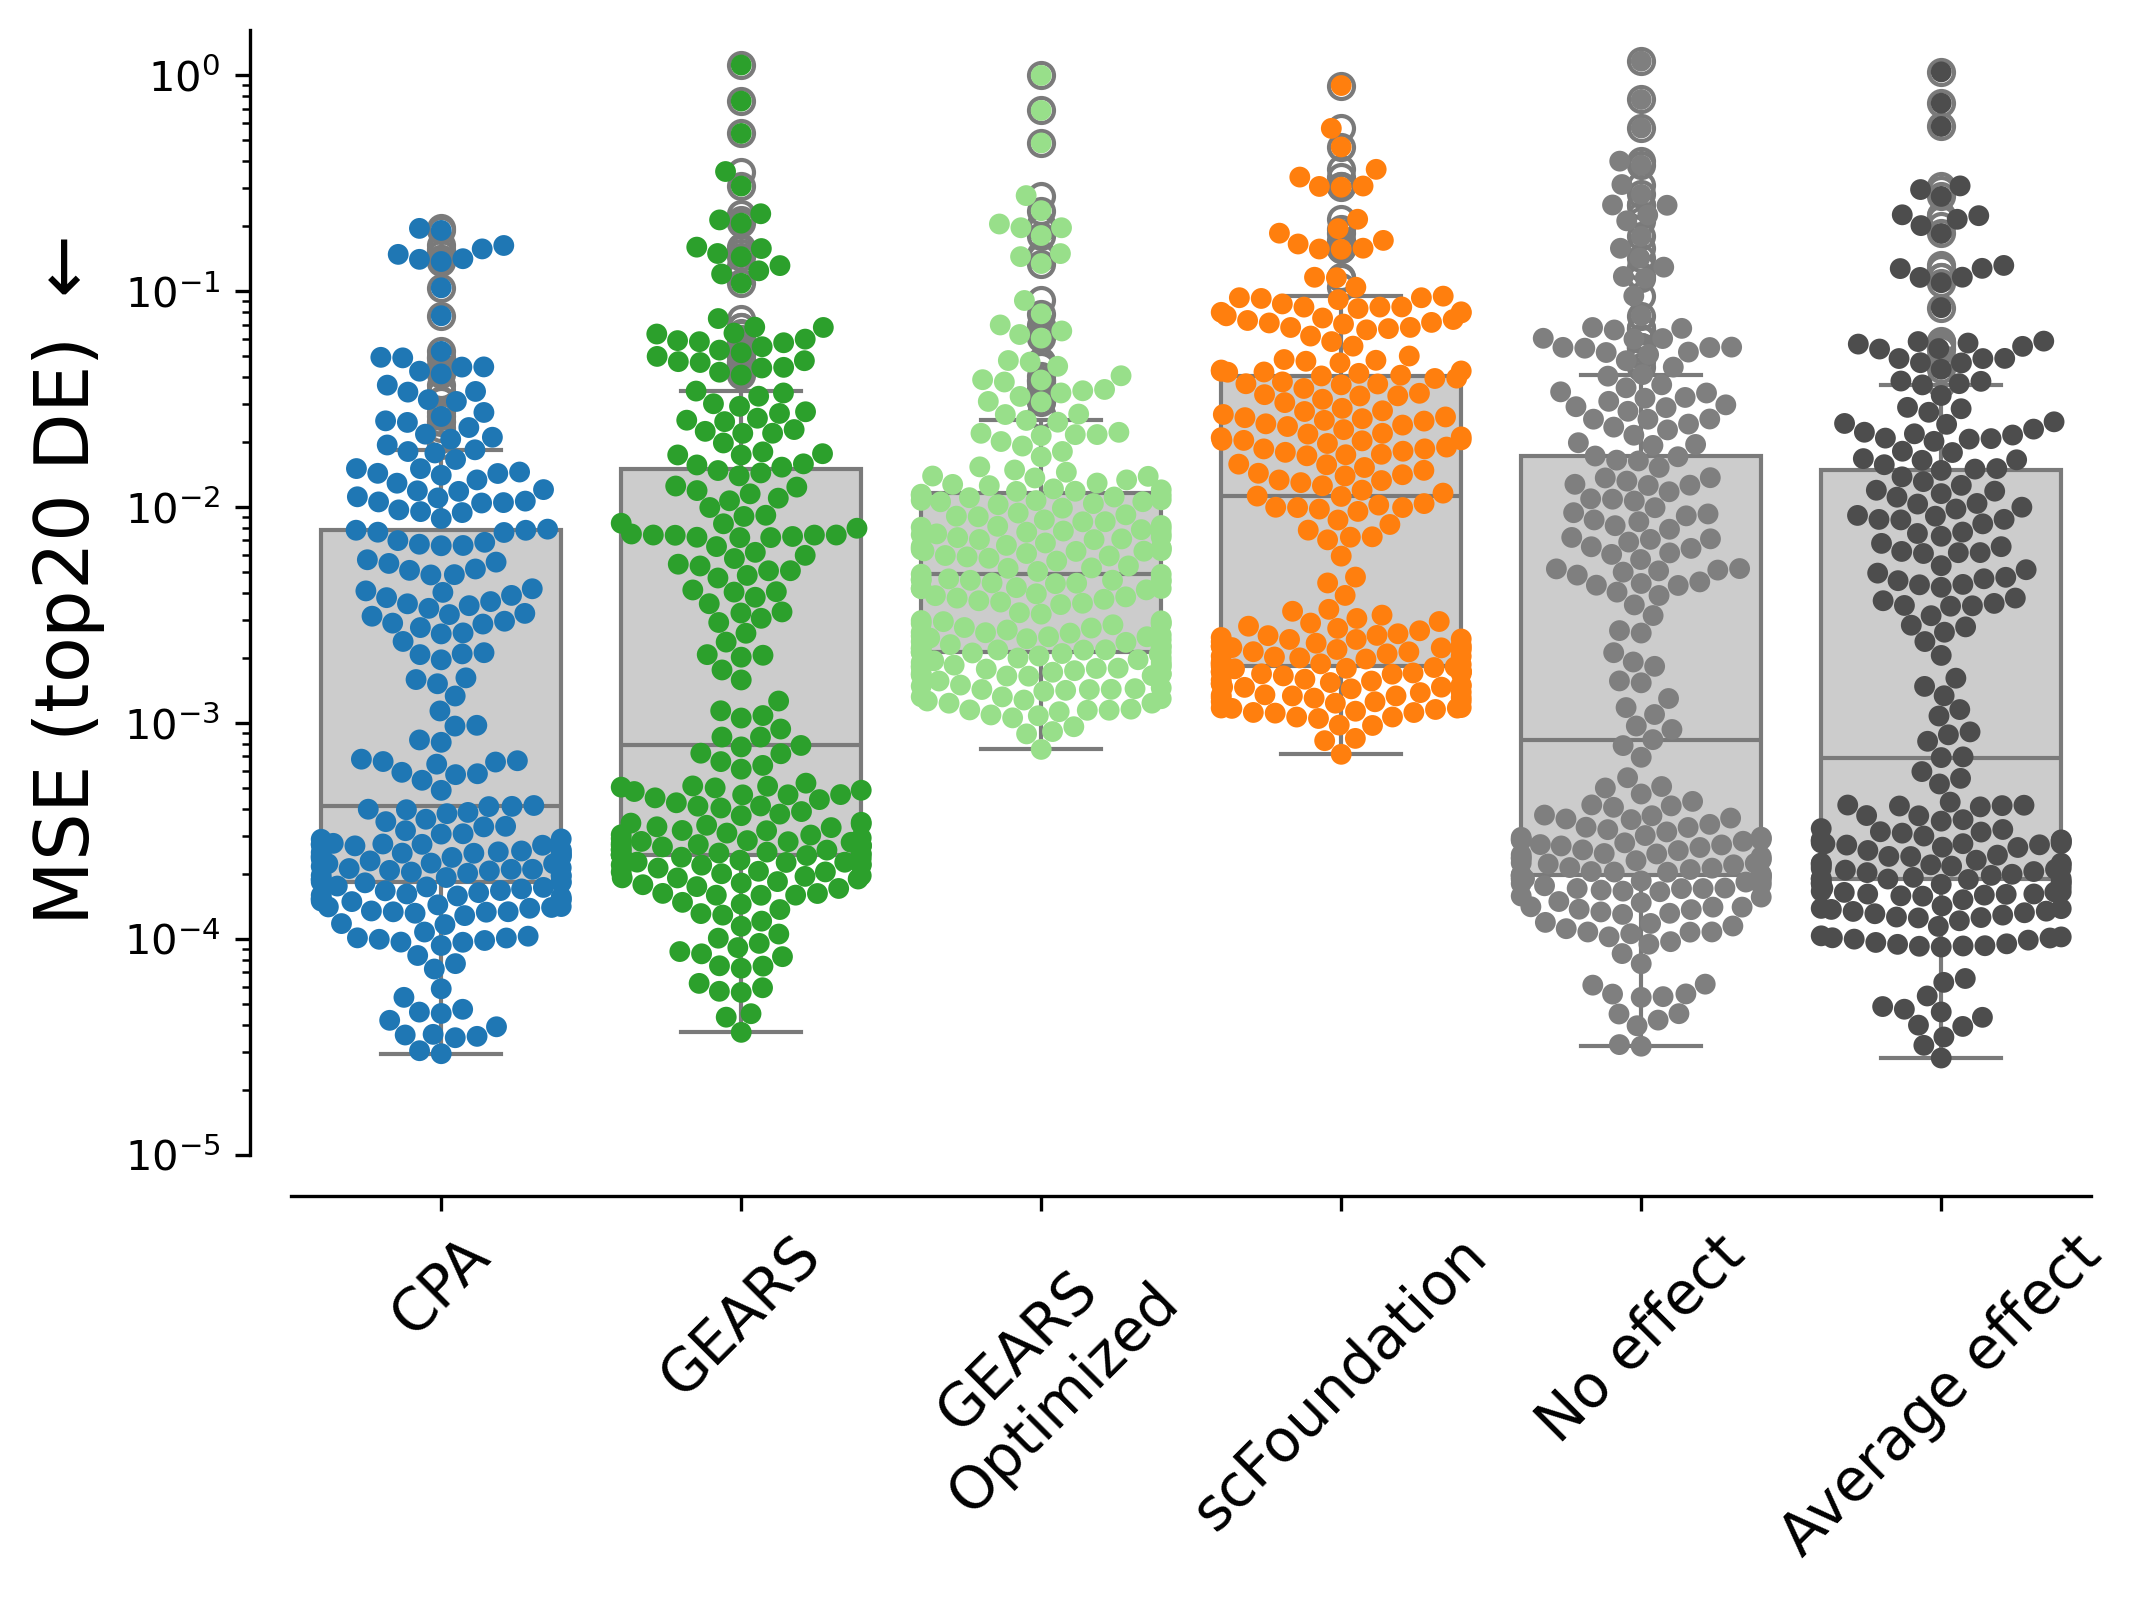

c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 18.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 39.0% of the points cannot be placed; you may want to decrease the size of the markers or use strip

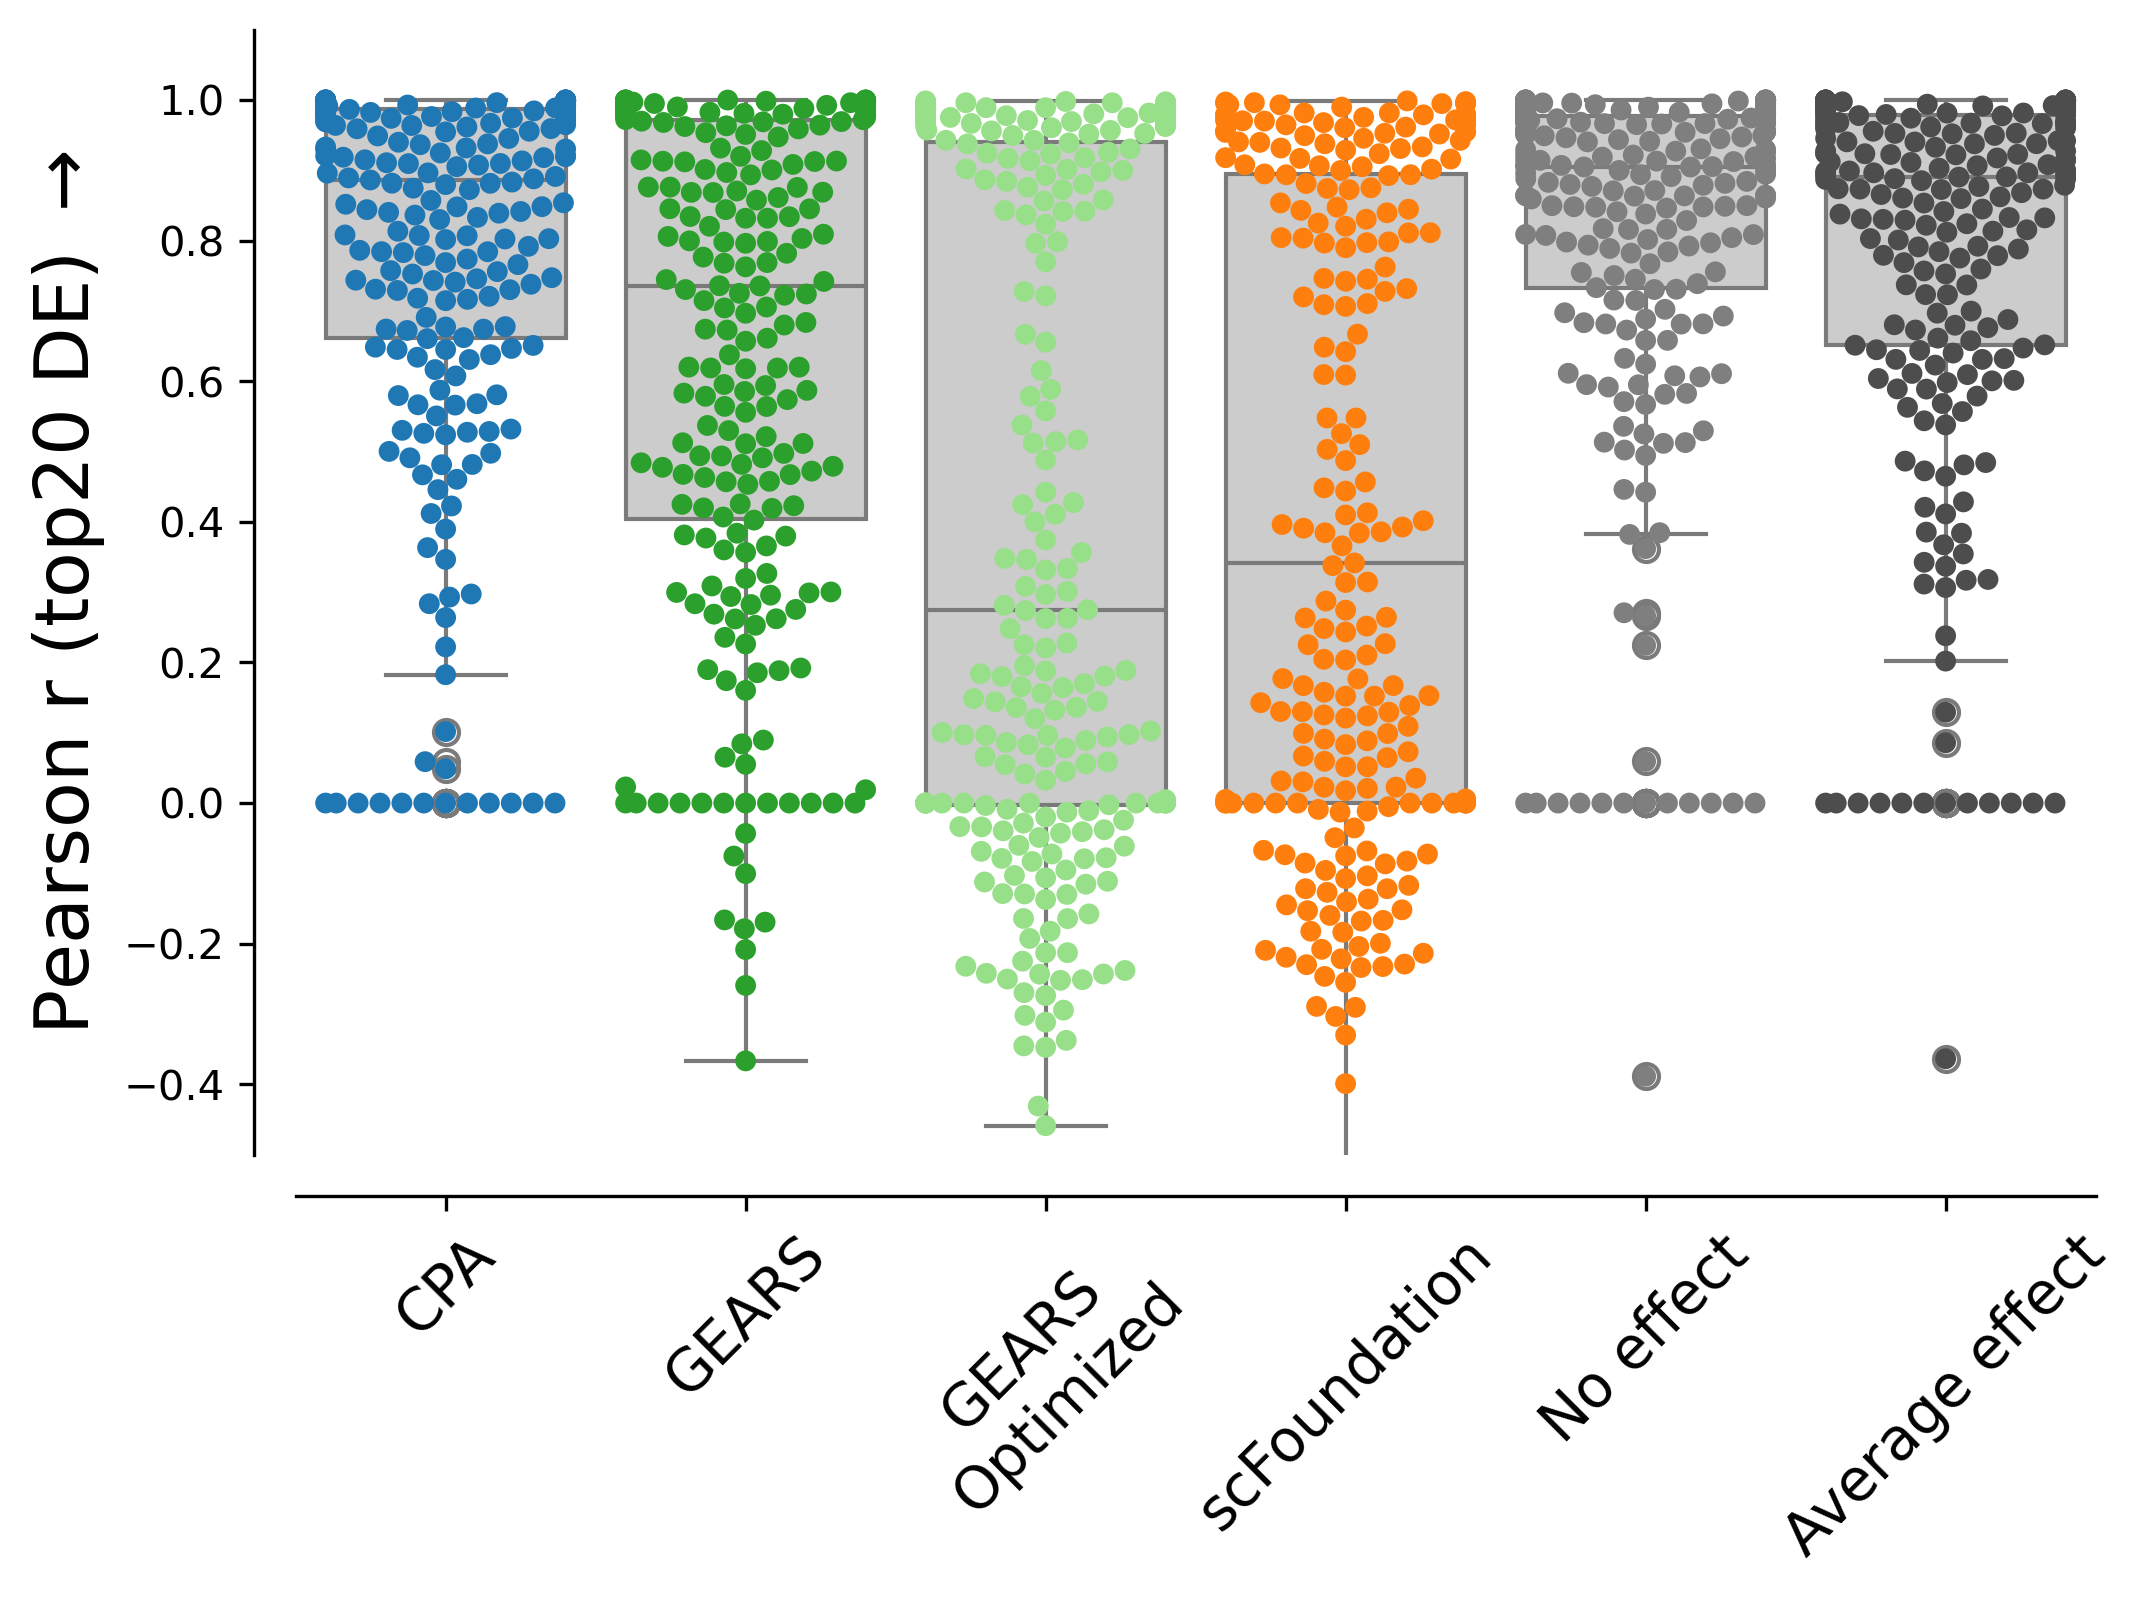

In [24]:
fig, axes = plot_performances_boxplot(all_outcomes.dropna(), figures_dir)
plt.tight_layout()

fig.savefig(os.path.join(figures_dir, 'sciplex_performances_boxplot.pdf'), bbox_inches='tight', dpi=300)

plt.show()